In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from plotcm import plot_confusion_matrix

import pdb

torch.set_printoptions(linewidth=120)

In [23]:
train_set = torchvision.datasets.FashionMNIST(
    root='./data'
    ,train=True
    ,download=True
    ,transform=transforms.Compose([
        transforms.ToTensor()
    ])
)

In [24]:
train_loader = torch.utils.data.DataLoader(train_set
    ,batch_size=1000
    ,shuffle=False
)

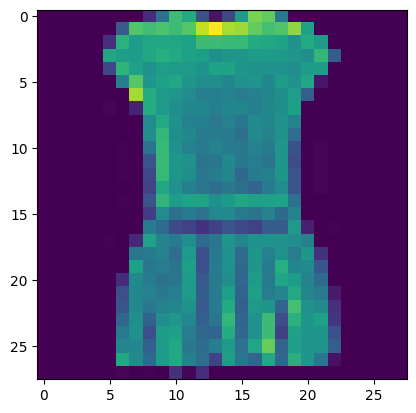

In [54]:
batch = next(iter(train_loader))
images , label = batch
images.shape
image = images[3]
image.shape
# plt.imshow(image.squeeze())
plt.imshow(image.permute(1,2,0))

In [1]:
#构建神经网络
import torch
import torch.nn as nn
import torch.functional as F

In [2]:
#构建神经网络的各层
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)

        self.fc1 = nn.Linear(in_features=12*4*4, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=60)
        self.out = nn.Linear(in_features=60, out_features=10)

    def forward(self, t):
        # implement the forward pass
        return t

In [3]:
network = Network()
print(network)
network

Network(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=192, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


Network(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=192, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)

In [ ]:
#实现前向传播函数
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)

        self.fc1 = nn.Linear(in_features=12*4*4, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=60)
        self.out = nn.Linear(in_features=60, out_features=10)

    def forward(self, t):
        # 1 input t
        t = t
        
        # 2 隐藏卷积层
        t = self.conv1(t)
        t = F.relu(t)
        t = F.max_pool2d(t,kernel_size=2,stride=2)
        
        # 3 隐藏卷积层
        t = self.conv2(t)
        t = F.relu(t)
        t = F.max_pool2d(t,kernel_size=2,stride=2)
        
        # 4 隐藏线性层
        t = t.reshape(-1, 12 * 4 * 4)  //展平二维[batch_size, features]   
        t = self.fc1(t)
        t = F.relu(t)
        
        # 5 隐藏线性层
        t = self.fc2(t)
        t = F.relu(t)
        
        # (6) output layer
        t = self.out(t)
        #t = F.softmax(t, dim=1)
        return t

In [17]:
# 23 使用卷积神经网络从数据集的样本图像生成输出预测张量

import torch
import torch.nn as nn 
import torch.nn.functional as F

In [18]:
torch.set_grad_enabled(False) #关闭pytorch的梯度计算特性，不构建计算图去计算梯度，减少内存消耗
                               #在训练时才打开，用于计算梯度更新权重

In [19]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5)
        self.conv2=nn.Conv2d(in_channels=6,out_channels=12,kernel_size=5)
        self.fc1 = nn.Linear(in_features=12*4*4,out_features=120)
        self.fc2 = nn.Linear(in_features=120,out_features=60)
        self.out = nn.Linear(in_features=60,out_features=10)
  

    def forward(self,t):
        t = t;

        t = self.conv1(t)
        t = F.relu(t)
        t = F.max_pool2d(t,kernel_size=2,stride=2)

        t = self.conv2(t)
        t = F.relu(t)
        t = F.max_pool2d(t,kernel_size=2,stride=2)

        t = t.reshape(-1,12*4*4)
        t = self.fc1(t)
        t = F.relu(t)

        t = self.fc2(t)
        t = F.relu(t)

        t = self.out(t)
        return t;
  

In [11]:
network = Network()

In [9]:
sample = next(iter(train_set))  #针对训练集的查看

In [13]:
images, label = sample    
images.shape     

torch.Size([1, 28, 28])

In [17]:
images.unsqueeze(dim=0).shape

torch.Size([1, 1, 28, 28])

In [21]:
pred = network(images.unsqueeze(dim=0))
pred.shape

torch.Size([1, 10])

In [22]:
pred

tensor([[-0.0357,  0.1633, -0.0716,  0.0839,  0.1050, -0.1210,  0.0967, -0.0188,  0.0321,  0.1236]])

In [26]:
pred.argmax(dim=1)

tensor([1])

In [27]:
F.softmax(pred, dim = 1)

tensor([[0.0927, 0.1132, 0.0895, 0.1045, 0.1068, 0.0852, 0.1059, 0.0943, 0.0992, 0.1088]])

In [28]:
F.softmax(pred, dim = 1).sum()

tensor(1.0000)

# 将一批图像传到网络(Dataloader)

In [7]:
train_set = torchvision.datasets.FashionMNIST(
    root='./data'
    ,train=True
    ,download=True
    ,transform=transforms.Compose([
        transforms.ToTensor()
    ])
)

In [8]:
data_loader = torch.utils.data.DataLoader(train_set,batch_size=10)

我们将从数据加载器中提取一批，并从该批中解压图像和标签张量。我们将使用复数形式来命名变量，因为我们知道在调用数据加载器迭代器的next时，数据加载器将返回一批10个图像。

In [4]:
batch = next(iter(data_loader))
images,labels = batch

查看pytorch和torchvision版本

In [6]:
print(torch.__version__)
print(torchvision.__version__)

1.12.0+cu113
0.13.0+cu113


In [9]:
images.shape

torch.Size([10, 1, 28, 28])

In [13]:
pred = network(images)
pred

tensor([[-0.1315,  0.0162, -0.1807, -0.0273,  0.0388,  0.1225, -0.0463,  0.1367, -0.0364, -0.1133],
        [-0.1379,  0.0228, -0.1858, -0.0288,  0.0353,  0.1218, -0.0345,  0.1380, -0.0363, -0.1109],
        [-0.1356,  0.0237, -0.1677, -0.0432,  0.0291,  0.1256, -0.0488,  0.1420, -0.0346, -0.1135],
        [-0.1371,  0.0235, -0.1713, -0.0391,  0.0313,  0.1264, -0.0476,  0.1451, -0.0364, -0.1112],
        [-0.1358,  0.0286, -0.1782, -0.0325,  0.0279,  0.1240, -0.0475,  0.1377, -0.0406, -0.1090],
        [-0.1342,  0.0201, -0.1857, -0.0317,  0.0304,  0.1237, -0.0401,  0.1338, -0.0350, -0.1103],
        [-0.1384,  0.0216, -0.1686, -0.0391,  0.0297,  0.1288, -0.0516,  0.1369, -0.0312, -0.1158],
        [-0.1320,  0.0200, -0.1816, -0.0361,  0.0292,  0.1241, -0.0479,  0.1354, -0.0395, -0.1145],
        [-0.1412,  0.0222, -0.1632, -0.0424,  0.0390,  0.1271, -0.0494,  0.1422, -0.0318, -0.1121],
        [-0.1283,  0.0117, -0.1719, -0.0350,  0.0380,  0.1252, -0.0457,  0.1377, -0.0345, -0.1096]],

In [14]:
pred.argmax(dim=1)

tensor([7, 7, 7, 7, 7, 7, 7, 7, 7, 7])

In [22]:
labels

tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5])

In [23]:
pred.argmax(dim=1).eq(labels)

tensor([False, False, False, False, False, False,  True, False, False, False])

In [24]:
pred.argmax(dim=1).eq(labels).sum()

tensor(1)

In [26]:
#包装成函数，用来判断预测正确的图片的个数
def get_num_correct(pred,labels):
    return pred.argmax(dim=1).eq(labels).sum()

In [27]:
get_num_correct(pred,labels)

tensor(1)

# stacking和concatenating

In [1]:
import torch

In [2]:
t1 = torch.tensor([1,1,1])
t2 = torch.tensor([2,2,2])
t3 = torch.tensor([3,3,3])

In [3]:
torch.cat(
    (t1,t2,t3),
    dim = 0
)

tensor([1, 1, 1, 2, 2, 2, 3, 3, 3])

In [6]:
torch.stack(
    (t1,t2,t3),
    dim=0
)

tensor([[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]])

In [9]:
torch.cat(
    (
        t1.unsqueeze(dim=0),
        t2.unsqueeze(dim=0),
        t3.unsqueeze(dim=0),
    ),
    dim=0
)

tensor([[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]])

In [7]:
torch.stack(
    (t1,t2,t3),
    dim=1
)

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])

In [10]:
torch.cat(
    (
        t1.unsqueeze(dim=1),
        t2.unsqueeze(dim=1),
        t3.unsqueeze(dim=1),
    ),
    dim=1
)

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])

In [11]:
t1.unsqueeze(dim=1)

tensor([[1],
        [1],
        [1]])

In [14]:
torch.cat(
    (
        t1.unsqueeze(dim=1),
        t2.unsqueeze(dim=1),
        t3.unsqueeze(dim=1),
    ),
    dim=0
)

tensor([[1],
        [1],
        [1],
        [2],
        [2],
        [2],
        [3],
        [3],
        [3]])

In [17]:
??torch.cat

# tensorboard

In [28]:
import torch
from torch.utils.tensorboard import SummaryWriter

In [29]:
print(torch.__version__
      )

1.12.0+cu113


In [30]:
!pip install tensorboard

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [14]:
!tensorboard --version

2.20.0


TensorFlow installation not found - running with reduced feature set.


In [ ]:
!pip uninstall Pillow

传一批图像

In [31]:
tb = SummaryWriter()

network = Network()
images,labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images)

tb.add_image('image',grid)
tb.add_graph(network,images)
tb.close()

AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'

# 使用TensorBoard快速试验不同的训练超参数

In [6]:
for name,weight in network.named_parameters():
    print(name,weight.shape)

conv1.weight torch.Size([6, 1, 5, 5])
conv1.bias torch.Size([6])
conv2.weight torch.Size([12, 6, 5, 5])
conv2.bias torch.Size([12])
fc1.weight torch.Size([120, 192])
fc1.bias torch.Size([120])
fc2.weight torch.Size([60, 120])
fc2.bias torch.Size([60])
out.weight torch.Size([10, 60])
out.bias torch.Size([10])


In [10]:
for name,weight in network.named_parameters():
    print(f'{name}.grad: ', weight.grad)

conv1.weight.grad:  None
conv1.bias.grad:  None
conv2.weight.grad:  None
conv2.bias.grad:  None
fc1.weight.grad:  None
fc1.bias.grad:  None
fc2.weight.grad:  None
fc2.bias.grad:  None
out.weight.grad:  None
out.bias.grad:  None


In [11]:
#前期准备
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

torch.set_printoptions(linewidth=120) #Display option for output
torch.set_grad_enabled(True)  #Already on by default

from torch.utils.tensorboard import SummaryWriter


class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)

        self.fc1 = nn.Linear(in_features=12*4*4, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=60)
        self.out = nn.Linear(in_features=60, out_features=10)

    def forward(self, t):
        # (1) input layer
        t = t

        # (2) hidden conv layer
        t = self.conv1(t)
        t = F.relu(t)
        t = F.max_pool2d(t, kernel_size=2, stride=2)

        # (3) hidden conv layer
        t = self.conv2(t)
        t = F.relu(t)
        t = F.max_pool2d(t, kernel_size=2, stride=2)

        # (4) hidden linear layer
        t = t.reshape(-1, 12 * 4 * 4)
        t = self.fc1(t)
        t = F.relu(t)

        # (5) hidden linear layer
        t = self.fc2(t)
        t = F.relu(t)

        # (6) output layer
        t = self.out(t)
        #t = F.softmax(t, dim=1)

        return t


def get_num_correct(pred,labels):
    return pred.argmax(dim=1).eq(labels).sum().item()


train_set = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True, 
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor()
    ])
)



In [ ]:
#硬编码超参数
batch_size = 100
lr=0.01

network = Network()
train_loader = torch.utils.data.DataLoader(train_set,batch_size)
optimizer = optim.Adam(network.parameters(), lr) 

images,labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images)

#tensorboard
comment = f"batch_size={batch_size} lr={lr}"
tb = SummaryWriter(comment=comment)
tb.add_image('image',grid)
tb.add_graph(network,images)

for epoch in range(5):
    print("epoch: ",epoch)
    train_epoch = 0
    train_corrcet = 0 #计算每个批次总共预测正确的数量
    total_loss = 0

    for batch in train_loader: #get batch
        images, labels = batch

        pred = network(images)
        loss = F.cross_entropy(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_epoch +=1
        total_loss += loss.item() * batch_size  # 乘以batch_size以适配不同batch_size
        train_corrcet += get_num_correct(pred,labels)


    tb.add_scalar("Loss",total_loss,epoch)
    tb.add_scalar("Number Correct",train_corrcet,epoch)
    tb.add_scalar("Accuracy",train_corrcet/len(train_set),epoch)


    # tb.add_histogram("conv1.bias",network.conv1.bias,epoch)
    # tb.add_histogram("conv1.weight",network.conv1.weight,epoch)
    # tb.add_histogram(
    #         'conv1.weight.grad'
    #         ,network.conv1.weight.grad
    #         ,epoch
    # )

    print("train_epoch: ", train_epoch, " train_loss: ", loss.item() , " correct_accuracy: ", train_corrcet/len(train_set)) 


tb.close()

In [12]:
from itertools import product

In [13]:
parameters = dict(
    lr = [.01, .001]
    ,batch_size = [100, 1000]
    ,shuffle = [True, False]
)

In [16]:
param_values = [v for v in parameters.values()]
param_values


[[0.01, 0.001], [100, 1000], [True, False]]

In [17]:
for lr,batch_size,shuffle in product(*param_values):
    print(lr,batch_size,shuffle)

0.01 100 True
0.01 100 False
0.01 1000 True
0.01 1000 False
0.001 100 True
0.001 100 False
0.001 1000 True
0.001 1000 False


In [ ]:
#主循环
for lr, batch_size, shuffle in product(*param_values): 
    comment = f' batch_size={batch_size} lr={lr} shuffle={shuffle}'
    
    #rest of data

# RunBuilder类

In [1]:
from collections import OrderedDict
from collections import namedtuple
from itertools import product

In [3]:
a = list(product([1, 2], ['a', 'b']))
a

[(1, 'a'), (1, 'b'), (2, 'a'), (2, 'b')]

In [5]:
class RunBuilder():
    @staticmethod
    def get_runs(params):
        # 假设params = {'lr': [0.01, 0.001], 'batch_size': [10, 100]}
        
        # 1. 创建命名元组类 "Run"，字段名来自字典的键
        Run = namedtuple('Run', params.keys())
        # 等价于：Run = namedtuple('Run', ['lr', 'batch_size'])
        # Run 现在有字段：Run(lr, batch_size)
        
        runs = []
        
        # 2. product(*params.values()) 生成所有组合，每个是一个元组
        #    (0.01, 10), (0.01, 100), (0.001, 10), (0.001, 100)
        for v in product(*params.values()):
            # v = (0.01, 10)  一个组合
            
            # 3. Run(*v) 解包传入，变成有名字的
            
            runs.append(Run(*v))
        	#    Run(0.01, 10) → 可以用 run.lr 访问
            
        return runs
        # [Run(lr=0.01, batch_size=10), Run(lr=0.01, batch_size=100), ...]
        # 因为Run本质还是元组，所以runs是一个元组列表

In [ ]:
parameters = OrdereDict(
    lr=[0.01,0.001]
    batch_size=[1000,10000]
)